In [12]:
# ============================================================
# CELL 1 : INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q tensorflow==2.21.0
!pip install -q tf-keras==2.21.0
!pip install -q transformers==4.41.2
!pip install -q datasets==2.20.0

!pip install -q emoji
!pip install -q contractions
!pip install -q unidecode
!pip install -q joblib

print("All packages installed successfully!")

All packages installed successfully!


In [13]:
!pip uninstall -y transformers
!pip install -q "transformers==4.41.2"

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2


In [14]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

import emoji
import contractions
import joblib

from unidecode import unidecode

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import AutoTokenizer, TFDistilBertForSequenceClassification

In [15]:
# ============================================================
# CELL 2 : LOAD DATASET
# ============================================================

import pandas as pd

# Change this if your CSV has a different name
CSV_PATH = "/content/emotions.csv"

df = pd.read_csv(CSV_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)
print(df.head())



Dataset Loaded Successfully
Shape : (416809, 2)
                                                text  label
0      i just feel really helpless and heavy hearted      4
1  ive enjoyed being able to slouch about relax a...      0
2  i gave up my internship with the dmrg and am f...      4
3                         i dont know i feel so lost      0
4  i am a kindergarten teacher and i am thoroughl...      4


In [16]:
# ============================================================
# CELL 2 : BASIC DATA ANALYSIS
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nEmotion Distribution")
print(df["label"].value_counts())

# ============================================================
# CELL 2 : REMOVE NULLS & DUPLICATES
# ============================================================

df = df.dropna()

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print("New Shape :", df.shape)





Missing Values
text     0
label    0
dtype: int64

Duplicate Rows : 686

Emotion Distribution
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64
New Shape : (416123, 2)


In [17]:
# import tensorflow as tf
# from transformers import TFDistilBertForSequenceClassification

# model = TFDistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased",
#     num_labels=NUM_CLASSES
# )

# model.compile(
#     optimizer="adam",
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# )

# model.load_weights("/content/drive/MyDrive/emotion_model/best_model.weights.h5")

# print("SUCCESS")

In [18]:
# ============================================================
# CELL 2 : TEXT PREPROCESSING
# ============================================================

import re
import emoji
import contractions
from unidecode import unidecode


def preprocess_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # expand contractions
    text = contractions.fix(text)

    # remove html
    text = re.sub(r"<.*?>", " ", text)

    # remove urls
    text = re.sub(r"http\S+|www\S+", " ", text)

    # remove email
    text = re.sub(r"\S+@\S+", " ", text)

    # remove emoji
    text = emoji.replace_emoji(text, replace="")

    # unicode normalize
    text = unidecode(text)

    # remove unwanted characters
    text = re.sub(r"[^a-zA-Z0-9.,!? ]", " ", text)

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

    # ============================================================
# APPLY PREPROCESSING
# ============================================================

df["text"] = df["text"].apply(preprocess_text)

print(df.head())

# ============================================================
# LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of Classes :", NUM_CLASSES)


# ============================================================
# TRAIN VALIDATION TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("="*60)

print("Training :", len(train_df))

print("Validation :", len(val_df))

print("Testing :", len(test_df))

print("="*60)


# ============================================================
# SAVE LABEL ENCODER
# ============================================================

import joblib

joblib.dump(label_encoder, "/content/label_encoder.pkl")

print("Label Encoder Saved")

                                                text  label
0      i just feel really helpless and heavy hearted      4
1  i have enjoyed being able to slouch about rela...      0
2  i gave up my internship with the dmrg and am f...      4
3                       i do not know i feel so lost      0
4  i am a kindergarten teacher and i am thoroughl...      4
[0 1 2 3 4 5]
Number of Classes : 6
Training : 332898
Validation : 41612
Testing : 41613
Label Encoder Saved


In [19]:
# ============================================================
# CELL 3 : LOAD TOKENIZER
# ============================================================

MODEL_NAME = "distilbert-base-uncased"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128

print("Tokenizer Loaded Successfully")

# ============================================================
# TOKENIZATION FUNCTION
# ============================================================

def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="tf"
    )

    # ============================================================
# TOKENIZE DATASETS
# ============================================================

train_encodings = tokenize(train_df["text"])

val_encodings = tokenize(val_df["text"])

test_encodings = tokenize(test_df["text"])

print("Tokenization Completed")

# ============================================================
# CREATE TF DATASETS
# ============================================================

import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_df["label"].values
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_df["label"].values
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_df["label"].values
))

print("TensorFlow Datasets Created")

# ============================================================
# OPTIMIZE DATA PIPELINE
# ============================================================

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("Datasets Optimized")

# ============================================================
# VERIFY DATASET
# ============================================================

for batch in train_dataset.take(1):
    x, y = batch

    print("Input IDs Shape:", x["input_ids"].shape)
    print("Attention Mask Shape:", x["attention_mask"].shape)
    print("Labels Shape:", y.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully
Tokenization Completed
TensorFlow Datasets Created
Datasets Optimized
Input IDs Shape: (16, 128)
Attention Mask Shape: (16, 128)
Labels Shape: (16,)


In [21]:
# ============================================================
# CELL 4 : LOAD TRAINED MODEL
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf

from transformers import (
    TFDistilBertForSequenceClassification,
    create_optimizer
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = "/content/drive/MyDrive/emotion_model"

NUM_CLASSES = len(label_encoder.classes_)

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 5

# ------------------------------------------------------------
# LOAD PRETRAINED DISTILBERT
# ------------------------------------------------------------

model = TFDistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

print("✅ Model Loaded Successfully")

# ------------------------------------------------------------
# CREATE OPTIMIZER
# ------------------------------------------------------------

steps_per_epoch = len(train_dataset)
num_train_steps = steps_per_epoch * EPOCHS

optimizer, schedule = create_optimizer(
    init_lr=LEARNING_RATE,
    num_train_steps=num_train_steps,
    num_warmup_steps=int(0.1 * num_train_steps),
    weight_decay_rate=WEIGHT_DECAY
)

# ------------------------------------------------------------
# COMPILE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

print("✅ Model Compiled Successfully")

# ------------------------------------------------------------
# BUILD MODEL (Required before loading weights)
# ------------------------------------------------------------

dummy_inputs = {
    "input_ids": tf.zeros((1, 128), dtype=tf.int32),
    "attention_mask": tf.ones((1, 128), dtype=tf.int32)
}

_ = model(dummy_inputs)

print("✅ Model Built")

# ------------------------------------------------------------
# LOAD SAVED WEIGHTS
# ------------------------------------------------------------

checkpoint_path = "/content/drive/MyDrive/emotion_model/best_model.weights.h5"

model.load_weights(checkpoint_path)

print("✅ Epoch-2 Weights Loaded Successfully")

print("=" * 60)
print("Model is ready for Evaluation and Inference.")
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

✅ Model Loaded Successfully
✅ Model Compiled Successfully
✅ Model Built
✅ Epoch-2 Weights Loaded Successfully
Model is ready for Evaluation and Inference.


In [22]:
import tensorflow as tf

checkpoint = "/content/drive/MyDrive/emotion_model/best_model.weights (1).h5"

try:
    loaded_model = tf.keras.models.load_model(
        checkpoint,
        compile=False
    )
    print("✅ Successfully loaded as a Keras model.")
    print(type(loaded_model))
except Exception as e:
    print("❌ Could not load as a Keras model.")
    print(e)

❌ Could not load as a Keras model.
No file or directory found at /content/drive/MyDrive/emotion_model/best_model.weights (1).h5


In [ ]:
model.load_weights(
    "/content/drive/MyDrive/emotion_model/best_model.weights.h5"
)

print("✅ Weights loaded successfully!")

In [31]:
# ============================================================
# CELL 5 : MODEL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# EVALUATE ON 5000 RANDOM TEST SAMPLES
# ------------------------------------------------------------

subset_df = test_df.sample(n=5000, random_state=42)

subset_encodings = tokenize(subset_df["text"])

subset_dataset = tf.data.Dataset.from_tensor_slices((
    dict(subset_encodings),
    subset_df["label"].values
)).batch(16)

print("=" * 60)
print("Evaluating model on 5000 test samples...")
print("=" * 60)

predictions = model.predict(subset_dataset)

y_pred = np.argmax(predictions.logits, axis=1)
y_true = subset_df["label"].values

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"\nTest Accuracy : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,

        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n✅ Model Evaluation Completed Successfully!")

Evaluating model on 5000 test samples...
 18/313 [>.............................] - ETA: 22:44

KeyboardInterrupt: 


Classification Report
              precision    recall  f1-score   support

           0     0.9753    0.9773    0.9763      1452
           1     0.9181    0.9869    0.9513      1682
           2     0.9962    0.6534    0.7892       401
           3     0.9682    0.9216    0.9443       727
           4     0.8451    0.9660    0.9015       559
           5     0.8601    0.6872    0.7640       179

    accuracy                         0.9348      5000
   macro avg     0.9272    0.8654    0.8878      5000
weighted avg     0.9380    0.9348    0.9323      5000



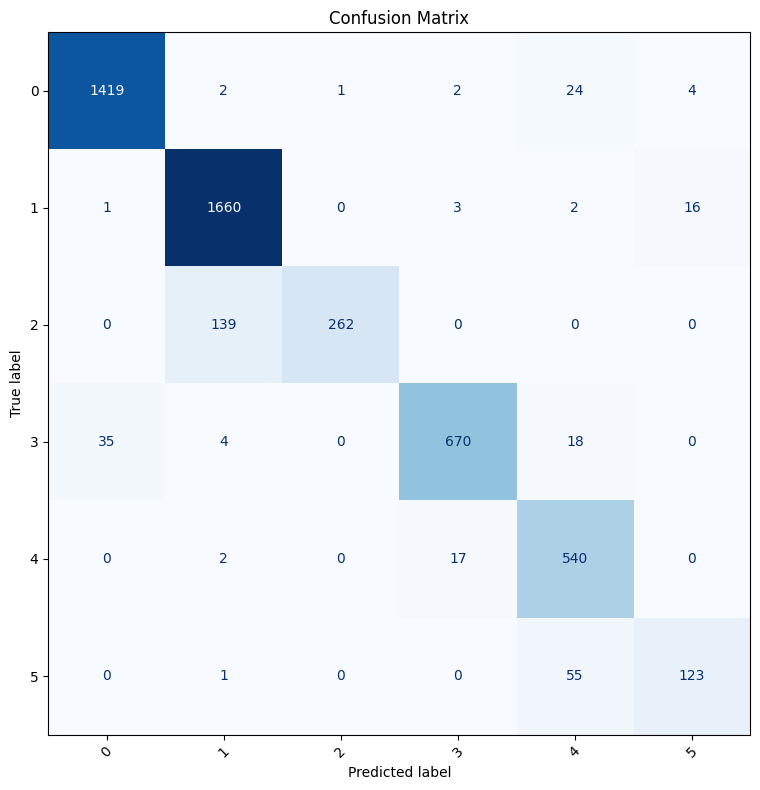


✅ Model Evaluation Completed Successfully!


In [30]:
#------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,

        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n✅ Model Evaluation Completed Successfully!")

In [32]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("Train batches:", len(train_dataset))
print("Validation batches:", len(val_dataset))
print("Test batches:", len(test_dataset))

Train: 332898
Validation: 41612
Test: 41613
Train batches: 20807
Validation batches: 2601
Test batches: 2601


In [33]:
# ============================================================
# CELL 6 : SAVE COMPLETE MODEL
# ============================================================

import os
import joblib

SAVE_DIR = "/content/drive/MyDrive/emotion_model/final_model"

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# SAVE TENSORFLOW MODEL
# ------------------------------------------------------------

model.save_pretrained(SAVE_DIR)

print("✅ TensorFlow model saved.")

# ------------------------------------------------------------
# SAVE TOKENIZER
# ------------------------------------------------------------

tokenizer.save_pretrained(SAVE_DIR)

print("✅ Tokenizer saved.")

# ------------------------------------------------------------
# SAVE LABEL ENCODER
# ------------------------------------------------------------

joblib.dump(
    label_encoder,
    os.path.join(SAVE_DIR, "label_encoder.pkl")
)

print("✅ Label Encoder saved.")

print("\nSaved Files:")

for file in sorted(os.listdir(SAVE_DIR)):
    print(file)

print("\n================================================")
print("Everything saved successfully.")
print("Location:", SAVE_DIR)
print("================================================")

✅ TensorFlow model saved.
✅ Tokenizer saved.
✅ Label Encoder saved.

Saved Files:
config.json
label_encoder.pkl
special_tokens_map.json
tf_model.h5
tokenizer.json
tokenizer_config.json
vocab.txt

Everything saved successfully.
Location: /content/drive/MyDrive/emotion_model/final_model


In [36]:
# ============================================================
# CELL 7 : PRODUCTION INFERENCE
# ============================================================

import os
import joblib
import tensorflow as tf
import numpy as np

from transformers import (
    DistilBertTokenizerFast,
    TFDistilBertForSequenceClassification
)

# ------------------------------------------------------------
# MODEL DIRECTORY
# ------------------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/emotion_model/final_model"

# ------------------------------------------------------------
# LOAD TOKENIZER
# ------------------------------------------------------------

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = TFDistilBertForSequenceClassification.from_pretrained(MODEL_DIR)

# ------------------------------------------------------------
# LOAD LABEL ENCODER
# ------------------------------------------------------------

label_encoder = joblib.load(
    os.path.join(MODEL_DIR, "label_encoder.pkl")
)

print("✅ Model Loaded Successfully")

# ------------------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------------------

MAX_LENGTH = 128

def predict_emotion(text):

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="tf"
    )

    outputs = model(**encoding)

    probabilities = tf.nn.softmax(outputs.logits, axis=-1).numpy()[0]

    prediction = np.argmax(probabilities)

    emotion = label_encoder.inverse_transform([prediction])[0]

    confidence = float(probabilities[prediction])

    return emotion, confidence, probabilities

# ------------------------------------------------------------
# TEST SENTENCES
# ------------------------------------------------------------

test_sentences = [
    "I am feeling extremely happy today.",
    "I am very sad and depressed.",
    "I am scared about tomorrow.",
    "I love spending time with my family.",
    "I am really angry with him.",
    "Wow! I didn't expect this at all."
]

# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

for text in test_sentences:

    emotion, confidence, probabilities = predict_emotion(text)

    print("=" * 60)
    print("Text       :", text)
    print("Prediction :", emotion)
    print("Confidence :", f"{confidence*100:.2f}%")

    print("\nProbabilities")

    for i, prob in enumerate(probabilities):
        print(f"Class {i}: {prob:.4f}")

    print("=" * 60)

Some layers from the model checkpoint at /content/drive/MyDrive/emotion_model/final_model were not used when initializing TFDistilBertForSequenceClassification: ['dropout_39']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at /content/drive/MyDrive/emotion_model/final_model and are newly initialized: ['dropout_79']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model Loaded Successfully
Text       : I am feeling extremely happy today.
Prediction : 1
Confidence : 99.99%

Probabilities
Class 0: 0.0000
Class 1: 0.9999
Class 2: 0.0000
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.0000
Text       : I am very sad and depressed.
Prediction : 0
Confidence : 87.47%

Probabilities
Class 0: 0.8747
Class 1: 0.0247
Class 2: 0.0042
Class 3: 0.0828
Class 4: 0.0132
Class 5: 0.0005
Text       : I am scared about tomorrow.
Prediction : 4
Confidence : 90.76%

Probabilities
Class 0: 0.0160
Class 1: 0.0589
Class 2: 0.0003
Class 3: 0.0168
Class 4: 0.9076
Class 5: 0.0005
Text       : I love spending time with my family.
Prediction : 1
Confidence : 72.79%

Probabilities
Class 0: 0.1165
Class 1: 0.7279
Class 2: 0.0659
Class 3: 0.0639
Class 4: 0.0230
Class 5: 0.0026
Text       : I am really angry with him.
Prediction : 3
Confidence : 92.11%

Probabilities
Class 0: 0.0428
Class 1: 0.0207
Class 2: 0.0015
Class 3: 0.9211
Class 4: 0.0130
Class 5: 0.0009
Text       : Wow! I